In [1]:
#!pip install mlflow cryptography==43.0.3 --ignore-installed blinker

  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached cryptography-43.0.3-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached gunicorn-26.0.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached huey

In [1]:
# Click on the '🔑' icon on the left panel, add a new secret named 'GH_TOKEN' and paste your PAT there.
from google.colab import userdata
import os

# Get the PAT from Colab secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Set it as an environment variable (optional, but good practice if cloning private repos)
os.environ['GH_TOKEN'] = GH_TOKEN

print("GitHub Token retrieved. You can now use it for cloning private repositories.")

GitHub Token retrieved. You can now use it for cloning private repositories.


In [2]:
# Replace with your GitHub email and username
!git config --global user.email "isaac_adebayojr@gmail.com"
!git config --global user.name "isaacadebayo"

print("Git user configured.")

Git user configured.


In [3]:
#Replace 'your_username' and 'your_repository' with your actual GitHub details.
# For a public repository:
!git clone https://github.com/isaacadebayo/Agentic_projects.git

# For a private repository using PAT:
# This uses the GH_TOKEN environment variable
!git clone https://{GH_TOKEN}@github.com/isaacadebayo/Agentic_projects

# Change into your repository directory to perform Git operations
%cd Agentic_projects

print("Repository cloned. You are now in the repository directory.")

fatal: destination path 'Agentic_projects' already exists and is not an empty directory.
fatal: destination path 'Agentic_projects' already exists and is not an empty directory.
/content/Agentic_projects
Repository cloned. You are now in the repository directory.


In [4]:
# Authenticate Google Cloud for DVC to access GCS
# This will open a browser window for authentication.
# Follow the instructions to get an authorization code and paste it back.
!gcloud auth application-default login

print("Google Cloud authentication complete. You can now retry the DVC push.")

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=DV50Ebyi0tVq7uDxTKv7jhEdC8Lkf2&prompt=consent&token_usage=remote&access_type=offline&code_challenge=hLPA9SEltlorWlYgmZUDtTFYjICAf_PpFmCc7IzkmQo&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPyAO_jkGdkb9XEeIb4QOYmohkt_X-o-UDi5ASFGlN4pKRuReSDTYheg8scjFIJJ3g

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [5]:
# Initialize DVC within the current directory (which is the cloned Git repo)
!dvc init

# Configure Google Drive as a remote storage (replace 'dvc_storage' with your desired folder name in Google Drive)
!dvc remote add -d gdrive_remote gdrive://MyDrive/dvc_storage
!dvc remote add -d gcs_remote gs://my-agentic-chatbot-data-lake

# Create a data directory within the Git repository if it doesn't exist
!mkdir -p data

# Copy the data file into the Git repository's data directory
# This ensures the .dvc file (created by dvc add) will be within the Git repo
!cp /content/drive/MyDrive/advertising.csv data/advertising.csv

# Add a data file to DVC. This will create a .dvc file at data/aapl_stock_prices.csv.dvc
!dvc add data/advertising.csv

# To commit the .dvc file to Git (requires Git setup, which is already done)
# Now git will find the .dvc file within its repository's working directory
!git add data/advertising.csv
!git commit -m "Add advertising.csv to DVC"

print("DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.")
print("You can push/pull changes using: !dvc push and !dvc pull")

/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Agentic_projects/
	mlartifacts/

nothing added to commit but untracked files present (use "git add" to track)
DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.
You can push/pull changes using: !dvc push and !dvc pull


In [6]:
import os
from google.colab import userdata

# Get your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the authtoken
!ngrok authtoken {NGROK_AUTH_TOKEN}

print("ngrok authtoken configured.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
ngrok authtoken configured.


In [7]:
import mlflow

mlflow.set_experiment("Ad Click Algorithm Prediction")

print("MLflow experiment for predicting if user engaged with an Ad")

MLflow experiment for predicting if user engaged with an Ad


In [8]:
!pip install pyngrok


In [8]:
import subprocess, time, requests, os, re
from pyngrok import ngrok
from google.colab import userdata

# ── 1. Kill everything ────────────────────────────────────────────
subprocess.run("pkill -f 'mlflow server'", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
time.sleep(3)

# ── 2. Start MLflow ───────────────────────────────────────────────
env = os.environ.copy()
env["GUNICORN_CMD_ARGS"] = "--forwarded-allow-ips='*'"

subprocess.Popen(
    ["mlflow", "server",
     "--backend-store-uri", "sqlite:////content/Agentic_projects/mlflow.db",
     "--serve-artifacts",
     "--host", "0.0.0.0",
     "--port", "5000",
     "--cors-allowed-origins", "https://ia-mlflow-dashboard.ngrok.app"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
    cwd="/content/Agentic_projects",
    env=env
)

print("Waiting for MLflow...")
for i in range(30):
    try:
        r = requests.get("http://localhost:5000/health", timeout=3)
        if r.status_code == 200:
            print(f"MLflow ready")
            break
    except Exception:
        pass
    time.sleep(2)

# ── 3. Write proxy (rewrites Host header to localhost:5000) ────────
proxy_code = """
import http.server
import http.client
import urllib.parse

class Proxy(http.server.BaseHTTPRequestHandler):
    def _proxy(self, body=None):
        parsed = urllib.parse.urlparse(f"http://localhost:5000{self.path}")

        conn = http.client.HTTPConnection("localhost", 5000, timeout=30)

        headers = dict(self.headers)
        headers["Host"] = "localhost:5000"
        headers["X-Forwarded-Host"] = "localhost:5000"
        headers["X-Forwarded-Proto"] = "http"
        headers.pop("Transfer-Encoding", None)
        headers.pop("transfer-encoding", None)

        try:
            conn.request(self.command, parsed.path + (f"?{parsed.query}" if parsed.query else ""), body=body, headers=headers)
            resp = conn.getresponse()

            self.send_response(resp.status)

            for k, v in resp.getheaders():
                if k.lower() not in ("transfer-encoding", "connection", "keep-alive"):
                    self.send_header(k, v)
            self.send_header("Access-Control-Allow-Origin", "*")
            self.send_header("Access-Control-Allow-Headers", "*")
            self.end_headers()

            # Stream response in chunks — fixes chart data loading
            while True:
                chunk = resp.read(8192)
                if not chunk:
                    break
                self.wfile.write(chunk)
            self.wfile.flush()

        except Exception as e:
            self.send_response(502)
            self.end_headers()
            self.wfile.write(str(e).encode())
        finally:
            conn.close()

    def do_GET(self):     self._proxy()
    def do_POST(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length) if length else None)
    def do_PUT(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length) if length else None)
    def do_DELETE(self):  self._proxy()
    def do_OPTIONS(self):
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Access-Control-Allow-Methods", "GET, POST, PUT, DELETE, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "*")
        self.end_headers()
    def log_message(self, *args): pass

server = http.server.HTTPServer(('0.0.0.0', 5001), Proxy)
server.serve_forever()
"""

with open("proxy.py", "w") as f:
    f.write(proxy_code)

subprocess.Popen(["python", "proxy.py"],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Proxy started on port 5001")
time.sleep(3)

# ── 4. Connect ngrok to proxy on port 5001 ────────────────────────
ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))

# Replace with your custom domain
public_url = ngrok.connect(5001, domain="ia-mlflow-dashboard.ngrok.app")
print(f"\nMLflow UI: {public_url}\n")

Waiting for MLflow...
MLflow ready
Proxy started on port 5001

MLflow UI: NgrokTunnel: "https://ia-mlflow-dashboard.ngrok.app" -> "http://localhost:5001"



In [10]:
#!pip install tensorflow

In [13]:
'''import mlflow
import os
import json
import mlflow.tensorflow # Import mlflow.tensorflow for Keras autologging

# Set the MLflow tracking URI to connect to the server started by ngrok
# The ngrok setup usually exposes localhost:5000
mlflow.set_tracking_uri("http://localhost:5000")

# Set an experiment name for better organization in the MLflow UI
mlflow.set_experiment("Ad Click Algorithm Prediction")

# Enable autologging for TensorFlow/Keras models
mlflow.tensorflow.autolog()

print("MLflow tensor tracking setup complete.")'''

'import mlflow\nimport os\nimport json\nimport mlflow.tensorflow # Import mlflow.tensorflow for Keras autologging\n\n# Set the MLflow tracking URI to connect to the server started by ngrok\n# The ngrok setup usually exposes localhost:5000\nmlflow.set_tracking_uri("http://localhost:5000")\n\n# Set an experiment name for better organization in the MLflow UI\nmlflow.set_experiment("Ad Click Algorithm Prediction")\n\n# Enable autologging for TensorFlow/Keras models\nmlflow.tensorflow.autolog()\n\nprint("MLflow tensor tracking setup complete.")'

In [13]:
#!pip install --force-reinstall --no-cache-dir "numpy==2.5.1" "scipy==1.17"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 521.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 579.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
  Attempting uninstall: scipy
    Found existing installation: scipy 1.18.0
    Uninstalling scipy-1.18.0:
      Successfully uninstalled scipy-1.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.55.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incom

# RUN FORCE REINSTALL SCIPY 1.17, RESTART AND COMMENT OUT, RUN FROM AUTHENTICATION AND RUN AUTOLOG SKLEARN, TWO RESTART SESSION ON AFTER INSTALLING CRYPTOGRAPHY AND ONE AFTER REINSTALL SCIPY

In [9]:
import mlflow
import os
import json
import mlflow.sklearn

# Set the MLflow tracking URI to connect to the server started by ngrok
# The ngrok setup usually exposes localhost:5000
mlflow.set_tracking_uri("http://localhost:5000")

# Set an experiment name for better organization in the MLflow UI
mlflow.set_experiment("Ad Click Algorithm Prediction")

# Enable autologging for scikit-learn models
mlflow.sklearn.autolog()

print("MLflow sklearn tracking setup complete.")

MLflow sklearn tracking setup complete.


In [10]:
import numpy, sys, os; print('numpy file:', numpy.__file__); print('numpy ver:', numpy.__version__); print('cwd:', os.getcwd()); print('path0:', sys.path[:4])

numpy file: /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
numpy ver: 2.5.1
cwd: /content/Agentic_projects
path0: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12']


In [11]:
import requests

# Check experiment directly
exp = requests.get(
    "http://localhost:5000/api/2.0/mlflow/experiments/get?experiment_id=1"
).json()
print("Experiment artifact location:", exp["experiment"]["artifact_location"])

# Check run artifact URIs
runs = requests.post(
    "http://localhost:5000/api/2.0/mlflow/runs/search",
    json={"experiment_ids": ["1"], "max_results": 50}
).json()

for run in runs.get("runs", []):
    print(f"{run['info']['run_name']} | artifact_uri: {run['info']['artifact_uri']}")

Experiment artifact location: mlflow-artifacts:/1
learned-ram-699 | artifact_uri: mlflow-artifacts:/1/00b21f8e5f4d421e813b7e11a75af2ed/artifacts
painted-sponge-240 | artifact_uri: mlflow-artifacts:/1/02f10ca5c7e14314ac2d5b1785664f2a/artifacts
calm-roo-560 | artifact_uri: mlflow-artifacts:/1/15bae061e86f4fa29266342872fc8c8b/artifacts
peaceful-perch-732 | artifact_uri: mlflow-artifacts:/1/23d21037fa3e4ac188e3009e2f6dfa6d/artifacts
persistent-deer-640 | artifact_uri: mlflow-artifacts:/1/a3b0bf6a05a74ca3808849fea920c545/artifacts
bedecked-asp-525 | artifact_uri: mlflow-artifacts:/1/ab53fe777f514b0289a51c920f4216ac/artifacts
luxuriant-bat-191 | artifact_uri: mlflow-artifacts:/1/8d4c04d525744da09fca3238a5187444/artifacts
abrasive-finch-675 | artifact_uri: mlflow-artifacts:/1/a1a445e5301b49c9bae50d65942e127f/artifacts
illustrious-eel-111 | artifact_uri: mlflow-artifacts:/1/aa7937e9f1a94713b57880fbd9500bb1/artifacts
carefree-wren-675 | artifact_uri: mlflow-artifacts:/1/b6d87556c3004d21891de53e

In [12]:
import requests

runs = requests.post(
    "http://localhost:5001/api/2.0/mlflow/runs/search",
    json={"experiment_ids": ["1"], "max_results": 50}
).json()

for run in runs.get("runs", []):
    info = run["info"]
    print(f"{info['run_name']} | artifact_uri: {info['artifact_uri']}")

learned-ram-699 | artifact_uri: mlflow-artifacts:/1/00b21f8e5f4d421e813b7e11a75af2ed/artifacts
painted-sponge-240 | artifact_uri: mlflow-artifacts:/1/02f10ca5c7e14314ac2d5b1785664f2a/artifacts
calm-roo-560 | artifact_uri: mlflow-artifacts:/1/15bae061e86f4fa29266342872fc8c8b/artifacts
peaceful-perch-732 | artifact_uri: mlflow-artifacts:/1/23d21037fa3e4ac188e3009e2f6dfa6d/artifacts
persistent-deer-640 | artifact_uri: mlflow-artifacts:/1/a3b0bf6a05a74ca3808849fea920c545/artifacts
bedecked-asp-525 | artifact_uri: mlflow-artifacts:/1/ab53fe777f514b0289a51c920f4216ac/artifacts
luxuriant-bat-191 | artifact_uri: mlflow-artifacts:/1/8d4c04d525744da09fca3238a5187444/artifacts
abrasive-finch-675 | artifact_uri: mlflow-artifacts:/1/a1a445e5301b49c9bae50d65942e127f/artifacts
illustrious-eel-111 | artifact_uri: mlflow-artifacts:/1/aa7937e9f1a94713b57880fbd9500bb1/artifacts
carefree-wren-675 | artifact_uri: mlflow-artifacts:/1/b6d87556c3004d21891de53e23254773/artifacts
suave-seal-861 | artifact_uri: 

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
data = pd.read_csv('/content/drive/MyDrive/advertising.csv')
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [15]:
data.rename(columns={'Clicked on Ad': 'click'}, inplace=True)

In [16]:
data.shape

(1000, 10)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   click                     1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [18]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hour']      = data['Timestamp'].dt.hour
data['DayOfWeek'] = data['Timestamp'].dt.dayofweek
data['Month']     = data['Timestamp'].dt.month

drop_cols = ['Timestamp', 'Ad Topic Line', 'City', 'Country']
data.drop(columns=drop_cols, inplace=True)

# Final features
numeric_cols = ['Daily Time Spent on Site', 'Age',
                'Area Income', 'Daily Internet Usage',
                'Hour', 'DayOfWeek', 'Month']
binary_cols  = ['Male']   # already encoded

feature_cols = numeric_cols + binary_cols

Target Variable

In [19]:
X = data[feature_cols]
y = data['click']

Train test split

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



2026/07/04 22:09:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '09b1b42fc61f4f86a58828e0aa8bf84a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 22:09:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https:/

🏃 View run languid-hen-666 at: http://localhost:5000/#/experiments/1/runs/9c079464e07a462bb75dcd0c730279f4
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run peaceful-hound-235 at: http://localhost:5000/#/experiments/1/runs/303b9698ddd94deba0441763386c2a5f
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run languid-gnat-950 at: http://localhost:5000/#/experiments/1/runs/d082230da4b74ba2869ce5b4f3df527f
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run righteous-lynx-572 at: http://localhost:5000/#/experiments/1/runs/7383125bfe474af383fd01a6e3cc705e
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run sassy-stoat-513 at: http://localhost:5000/#/experiments/1/runs/46bee21c28fc4eeda9c6532c39df3546
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run agreeable-snake-789 at: http://localhost:5000/#/experiments/1/runs/09b1b42fc61f4f86a58828e0aa8bf84a
🧪 View experiment at: http://localhost:5000/#/e

2026/07/04 22:09:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/04 22:09:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely

🏃 View run honorable-ray-935 at: http://localhost:5000/#/experiments/1/runs/35ed85f9991f496698297e339a581a08
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run zealous-squid-788 at: http://localhost:5000/#/experiments/1/runs/20e019e0a1144f048c7884d48ed4d723
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run beautiful-dove-711 at: http://localhost:5000/#/experiments/1/runs/9473033863ee49a5a48e314cd69c03bd
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run mercurial-eel-604 at: http://localhost:5000/#/experiments/1/runs/2a81a3a632894a82abdb70bc32d623ac
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run sassy-lynx-919 at: http://localhost:5000/#/experiments/1/runs/bfdafc85440b4b3bb214108ff34a5f33
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/04 22:09:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1e44fc8dc777442d8c2291bf09027ced', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 22:09:58 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https:/

...

🏃 View run funny-horse-324 at: http://localhost:5000/#/experiments/1/runs/bdeee9d9fac64b749eb0ba006de33738
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run tasteful-squid-947 at: http://localhost:5000/#/experiments/1/runs/1c21f94d6b5446f38672b2c756315766
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run adorable-fox-407 at: http://localhost:5000/#/experiments/1/runs/f2365691133240658c5b256006ea1f31
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run upset-wolf-897 at: http://localhost:5000/#/experiments/1/runs/dc259e3f3b7143e68ff5f1fb346aaf83
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run lyrical-dove-705 at: http://localhost:5000/#/experiments/1/runs/19f9bf368714442fa319f606a4dc43e9
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run polite-perch-807 at: http://localhost:5000/#/experiments/1/runs/77c67ab575cf462f947bb6bba8fb10d2
🧪 View experiment at: http://localhost:5000/#/experim

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead o

                     Accuracy     F1  ROC-AUC
Logistic Regression     0.972  0.972    0.992
Random Forest           0.961  0.961    0.992
SVM                     0.970  0.970    0.992
Gradient Boosting       0.961  0.961    0.989

  Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       500
           1       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead o


  Random Forest
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       500
           1       0.97      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000


  Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       500
           1       0.96      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000


  SVM
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       500
           1       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      

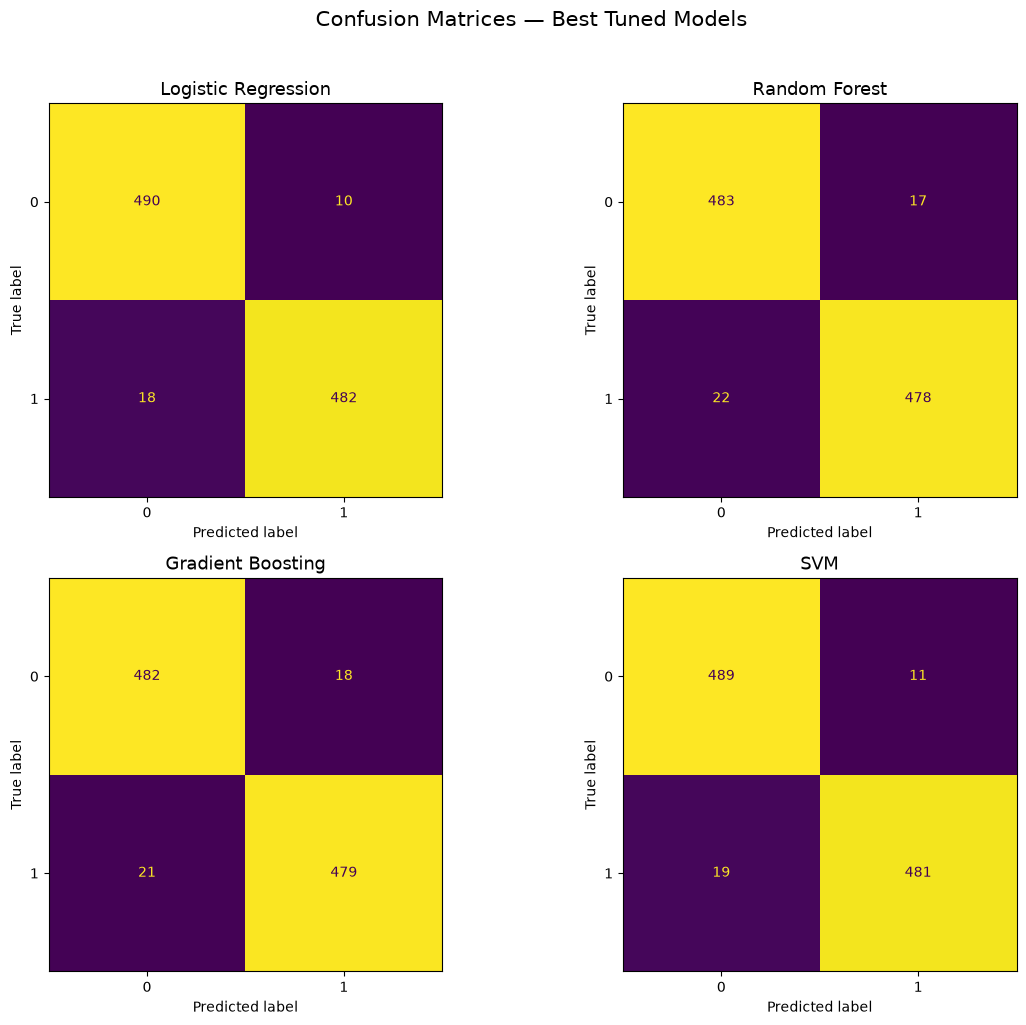

In [21]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Step 1: Define base pipelines ---
pipeline_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
pipeline_rf  = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))])
pipeline_gb  = Pipeline([('scaler', StandardScaler()), ('clf', GradientBoostingClassifier(random_state=42))])
pipeline_svm = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42, class_weight='balanced'))])

# --- Step 2: Tune each model with its own param grid ---
rf_params = {
    'clf__n_estimators':    [50, 100, 200],
    'clf__max_depth':       [5, 10, 15, None],
    'clf__max_leaf_nodes':  [20, 50, 100, None],
    'clf__min_samples_leaf':[5, 10, 20],
}

gb_params = {
    'clf__n_estimators':    [50, 100, 200],
    'clf__max_depth':       [3, 5, 10],
    'clf__learning_rate':   [0.01, 0.05, 0.1],
    'clf__min_samples_leaf':[5, 10, 20],
}

lr_params = {
    'clf__C':       [0.01, 0.1, 1, 10],    # regularization strength
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear'],          # needed for l1
}

svm_params = {
    'clf__C':      [0.1, 1, 10],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma':  ['scale', 'auto'],
}

searches = {
    'Logistic Regression': RandomizedSearchCV(pipeline_lr,  lr_params,  cv=cv, scoring='roc_auc', n_iter=10, random_state=42),
    'Random Forest':       RandomizedSearchCV(pipeline_rf,  rf_params,  cv=cv, scoring='roc_auc', n_iter=20, random_state=42),
    'Gradient Boosting':   RandomizedSearchCV(pipeline_gb,  gb_params,  cv=cv, scoring='roc_auc', n_iter=20, random_state=42),
    'SVM':                 RandomizedSearchCV(pipeline_svm, svm_params, cv=cv, scoring='roc_auc', n_iter=10, random_state=42),
}

# Fit all searches and collect best params
for name, search in searches.items():
    search.fit(X, y)
    print(f"{name} best params: {search.best_params_}")

# --- Step 3: Compare best versions of each model ---
results = {}
for name, search in searches.items():
    best_pipeline = search.best_estimator_   # ← tuned pipeline, not the original
    scores = cross_validate(best_pipeline, X, y, cv=cv,
                            scoring=['accuracy', 'f1', 'roc_auc'])
    results[name] = {
        'Accuracy': scores['test_accuracy'].mean().round(3),
        'F1':       scores['test_f1'].mean().round(3),
        'ROC-AUC':  scores['test_roc_auc'].mean().round(3),
    }

results_df = pd.DataFrame(results).T
print(results_df.sort_values('ROC-AUC', ascending=False))

# --- Step 4: Confusion matrix + Classification report for each best model ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, search) in enumerate(searches.items()):
    best_pipeline = search.best_estimator_

    # Get predictions across all folds
    y_pred = cross_val_predict(best_pipeline, X, y, cv=cv)

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=['No Conversion', 'Conversion'])
    disp.plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"{name}", fontsize=13)

    # Classification report printed below each matrix
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y, y_pred))#, target_names=['No Conversion', 'Conversion']))

plt.suptitle('Confusion Matrices — Best Tuned Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

# Example: a new user you want to score
new_user = pd.DataFrame([{
    'Daily Time Spent on Site': 75.0,   # minutes on site
    'Age': 32,
    'Area Income': 65000,
    'Daily Internet Usage': 210.0,
    'Hour': 14,                          # 2pm
    'DayOfWeek': 1,                      # Tuesday
    'Month': 6,
    'Male': 1
}])

# Use best model (Logistic Regression)
best_model = searches['Logistic Regression'].best_estimator_

prediction    = best_model.predict(new_user)[0]
probability   = best_model.predict_proba(new_user)[0][1]

print(f"Predicted:   {'Clicked ✓' if prediction == 1 else 'Not Clicked ✗'}")
print(f"Probability of clicking: {probability:.1%}")

Predicted:   Not Clicked ✗
Probability of clicking: 1.4%


Heavy internet user are ad blind

In [30]:
new_user = pd.DataFrame([{
    'Daily Time Spent on Site': 70.0,   # lower time = more likely to click
    'Age': 45,                           # older users click more in this dataset
    'Area Income': 45000,                # lower income = more receptive
    'Daily Internet Usage': 180.0,       # lower usage = more receptive
    'Hour': 9,
    'DayOfWeek': 2,
    'Month': 3,
    'Male': 0
}])

# Use best model (Logistic Regression)
best_model = searches['Logistic Regression'].best_estimator_

prediction    = best_model.predict(new_user)[0]
probability   = best_model.predict_proba(new_user)[0][1]

print(f"Predicted:   {'Clicked ✓' if prediction == 1 else 'Not Clicked ✗'}")
print(f"Probability of clicking: {probability:.1%}")

Predicted:   Clicked ✓
Probability of clicking: 96.7%


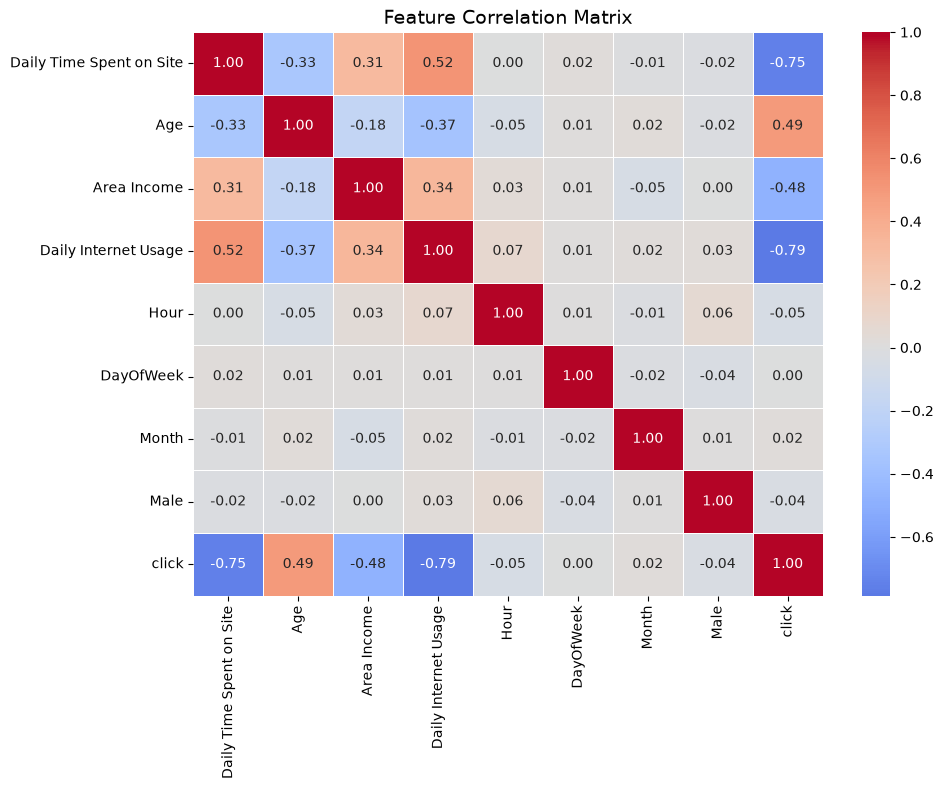

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data[feature_cols + ['click']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
from scipy.stats import pointbiserialr

print("Correlation with 'Clicked on Ad':\n")
for col in feature_cols:
    corr, pval = pointbiserialr(data['click'], data[col])
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {col:<30} r = {corr:+.3f}   p = {pval:.4f}  {sig}")

Correlation with 'Clicked on Ad':

  Daily Time Spent on Site       r = -0.748   p = 0.0000  ***
  Age                            r = +0.493   p = 0.0000  ***
  Area Income                    r = -0.476   p = 0.0000  ***
  Daily Internet Usage           r = -0.787   p = 0.0000  ***
  Hour                           r = -0.047   p = 0.1339  ns
  DayOfWeek                      r = +0.002   p = 0.9496  ns
  Month                          r = +0.016   p = 0.6112  ns
  Male                           r = -0.038   p = 0.2296  ns


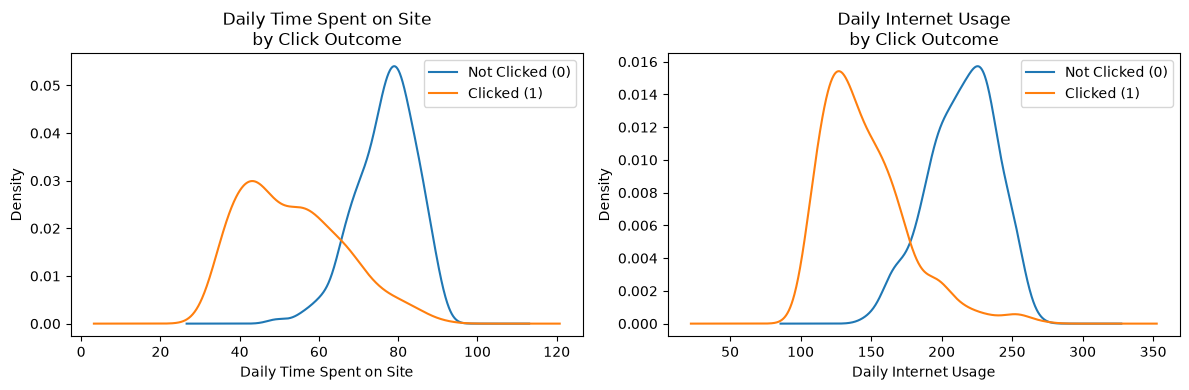

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['Daily Time Spent on Site', 'Daily Internet Usage']):
    data.groupby('click')[col].plot.kde(ax=ax, legend=True)
    ax.set_title(f'{col}\nby Click Outcome')
    ax.legend(['Not Clicked (0)', 'Clicked (1)'])
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

The negative correlation between time-on-site and clicking indicates that users who spend a lot of time on the site are likely already engaged with content and ignore ads, while users who land, don't find what they want, and bounce are more receptive to clicking out via an ad

In [28]:
import joblib

# Get the best Logistic Regression model from the search results
best_lr_model = searches['Logistic Regression'].best_estimator_

# Define the path to save the model locally within the Colab environment
model_path = 'Adclick_regression_model.joblib'

# Save the model
joblib.dump(best_lr_model, model_path)

print(f"Best Logistic Regression model saved locally to: {model_path}")
print("You can now download this file directly from the Colab file browser (left-hand sidebar).")

Best Logistic Regression model saved locally to: Adclick_regression_model.joblib
You can now download this file directly from the Colab file browser (left-hand sidebar).
